# Linear Discriminant Analysis (LDA)

In [1]:
import sys; sys.path.insert(0, "..")

from utils.dependencies import *
from utils import (
    load_and_filter, impute, split_and_balance, FEATURES,
    get_class_meta,
    run_grid_search,
    run_stratified_cv,
    run_seed_sweep, SweepResult,
    print_sweep_classification_report,
    print_sweep_performance_summary,
    print_sweep_error_patterns,
    plot_sweep_f1_bar, plot_sweep_confusion_matrix,
    plot_sweep_posterior_violins,
)

## Model-Specific Data Processing

In [2]:
df = load_and_filter()
df = impute(df)

LOG_COLS = ["pl_bmasse", "pl_orbper", "pl_orbsmax", "pl_eqt", "sy_dist"]
for col in LOG_COLS:
    df[col] = np.log1p(df[col].clip(lower=0))

for col in FEATURES:
    lo, hi = df[col].quantile([0.01, 0.99])
    df[col] = df[col].clip(lower=lo, upper=hi)

X_train_bal, y_train_bal, X_test_scaled, y_test, class_weight_dict, scaler = split_and_balance(df)

class_names, classes, colors = get_class_meta()
class_labels = [f"{n} ({i})" for i, n in enumerate(class_names)]

Loaded: (5569, 18)
Nulls before imputation:
pl_orbper       260
pl_orbsmax     2237
pl_orbeccen    3315
pl_bmasse      2986
pl_rade        1373
pl_eqt         2402
st_teff         290
st_rad          321
st_mass         206
st_lum          675
st_met          424
st_logg         351
st_age         1246
P_GRAVITY         7
P_DENSITY         7
P_ESCAPE          7
sy_dist         118
dtype: int64

[Tier 2a] pl_orbeccen: filled 3315 with 0.0
[Tier 2b] pl_orbsmax: filled 2203 via Kepler's 3rd law
[Tier 2c] pl_orbper: filled 242 via Kepler's 3rd law (inverse)
[Tier 2d] st_lum: filled 362 via Stefan-Boltzmann law
[Tier 2e] pl_bmasse: filled 2972 via mass-radius relation
[Tier 2f] pl_rade: filled 1359 via inverse mass-radius relation
[Tier 2g] pl_eqt: filled 2073 via equilibrium temp formula
[Tier 2h-j] P_GRAVITY/DENSITY/ESCAPE: filled 0 via physics formulas

Nulls after Tier 2:
pl_orbper        18
pl_orbsmax       34
pl_orbeccen       0
pl_bmasse        14
pl_rade          14
pl_eqt          

/Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


[Tier 4] RF Iterative Imputer on planetary features (train): 343 → 0 nulls
[Tier 5a] st_met: filled 343 via grouped median by spectral type (train)
[Tier 5b] st_age: filled 988 via RF regression + median fallback (train)
[Tier 6] KNN imputer (train): 97 → 0 nulls

Train distribution (BEFORE balancing):
P_HABITABLE
0.0    4399
1.0      23
2.0      33
Name: count, dtype: int64

Train distribution (AFTER balancing):
P_HABITABLE
0.0    300
1.0    200
2.0    199
Name: count, dtype: int64
Balanced train shape: (699, 17)
Class weights: {np.int64(0): np.float64(0.7766666666666666), np.int64(1): np.float64(1.165), np.int64(2): np.float64(1.170854271356784)}

Outputs ready for modeling:
  X_train_bal       → (699, 17) (balanced, scaled)
  y_train_bal       → 699 samples
  X_test_scaled     → (1114, 17) (held-out, scaled)
  y_test            → 1114 samples (original distribution)
  class_weight_dict → for class_weight param in classifiers


## Training

In [3]:
param_grid = [
    {"solver": ["svd"]},
    {"solver": ["lsqr", "eigen"], "shrinkage": ["auto", 0.0, 0.1, 0.25, 0.5, 0.75, 1.0]},
]

grid_lda = run_grid_search(LinearDiscriminantAnalysis(), param_grid, X_train_bal, y_train_bal)
lda = grid_lda.best_estimator_

y_pred_lda = lda.predict(X_test_scaled)
y_prob_lda = lda.predict_proba(X_test_scaled)

# Projection model for diagnostic plots (lsqr doesn't support .transform or .scalings_)
lda_proj = LinearDiscriminantAnalysis(
    solver="eigen",
    shrinkage=lda.shrinkage if hasattr(lda, "shrinkage") and lda.shrinkage is not None else "auto",
)
lda_proj.fit(X_train_bal, y_train_bal)
X_train_lda = lda_proj.transform(X_train_bal)
X_test_lda  = lda_proj.transform(X_test_scaled)

class_names, classes, colors = get_class_meta()
class_labels = [f"{n} ({i})" for i, n in enumerate(class_names)]

print(f"Best params: {grid_lda.best_params_}")
print(f"Best CV F1 Macro: {grid_lda.best_score_:.4f}")
print("LDA training complete.")
print(f"Number of discriminant components: {X_train_lda.shape[1]}")
print(f"Test predictions shape: {y_pred_lda.shape}")

Best params: {'solver': 'svd'}
Best CV F1 Macro: 0.8129
LDA training complete.
Number of discriminant components: 2
Test predictions shape: (1114,)


### Seed-Sweep Evaluation

Grid search above tuned the LDA solver (and shrinkage when applicable) on `random_state=42` only. With minority test classes at 6 mesoplanet and 8 psychroplanet samples, the single test F1 macro from one split is noisy. Re-evaluate with the same tuned hyperparameters across 50 random splits — capturing per-seed confusion matrices and predicted probabilities for downstream aggregated diagnostics.

LDA exposes `predict_proba` regardless of solver, so the sweep gets per-seed posterior distributions for the aggregated violin plot below. The discriminant-space diagnostics above (LD1/LD2 scatter, feature weights, class histograms) remain seed=42 because LDA's axes have sign and ordering ambiguity across fits — aggregating them would require Procrustes alignment for little gain in interpretability.

In [4]:
sweep_lda = run_seed_sweep(
    lambda cw: LinearDiscriminantAnalysis(**grid_lda.best_params_),
    df,
    n_seeds=50,
    model_name="LDA",
    save_csv="sweep_lda.csv",
    save_pickle="sweep_lda.pkl",
)

/Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
/Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
/Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
/Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
/Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/.venv/lib/python3.13/si

LDA — 50-seed sweep
  F1 macro:    0.4195 ± 0.0233  (SEM 0.0033, min 0.3732, max 0.4762)
  F1 weighted: 0.9262 ± 0.0083
  Captured per-seed: predict_proba
  F1 DataFrame saved to /Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/basic_models/../data/output/seed_sweep_results/sweep_lda.csv
  Full SweepResult pickled to /Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/basic_models/../data/output/seed_sweep_results/sweep_lda.pkl


## Modeling
### DIAGNOSTIC PLOT 1: LDA Discriminant Space — Decision Boundaries
LDA projects data onto axes that maximise class separation.  
With 3 classes we get exactly 2 discriminant axes (LD1, LD2).  
This IS the space where LDA makes its decisions and every prediction is a nearest-centroid lookup here.


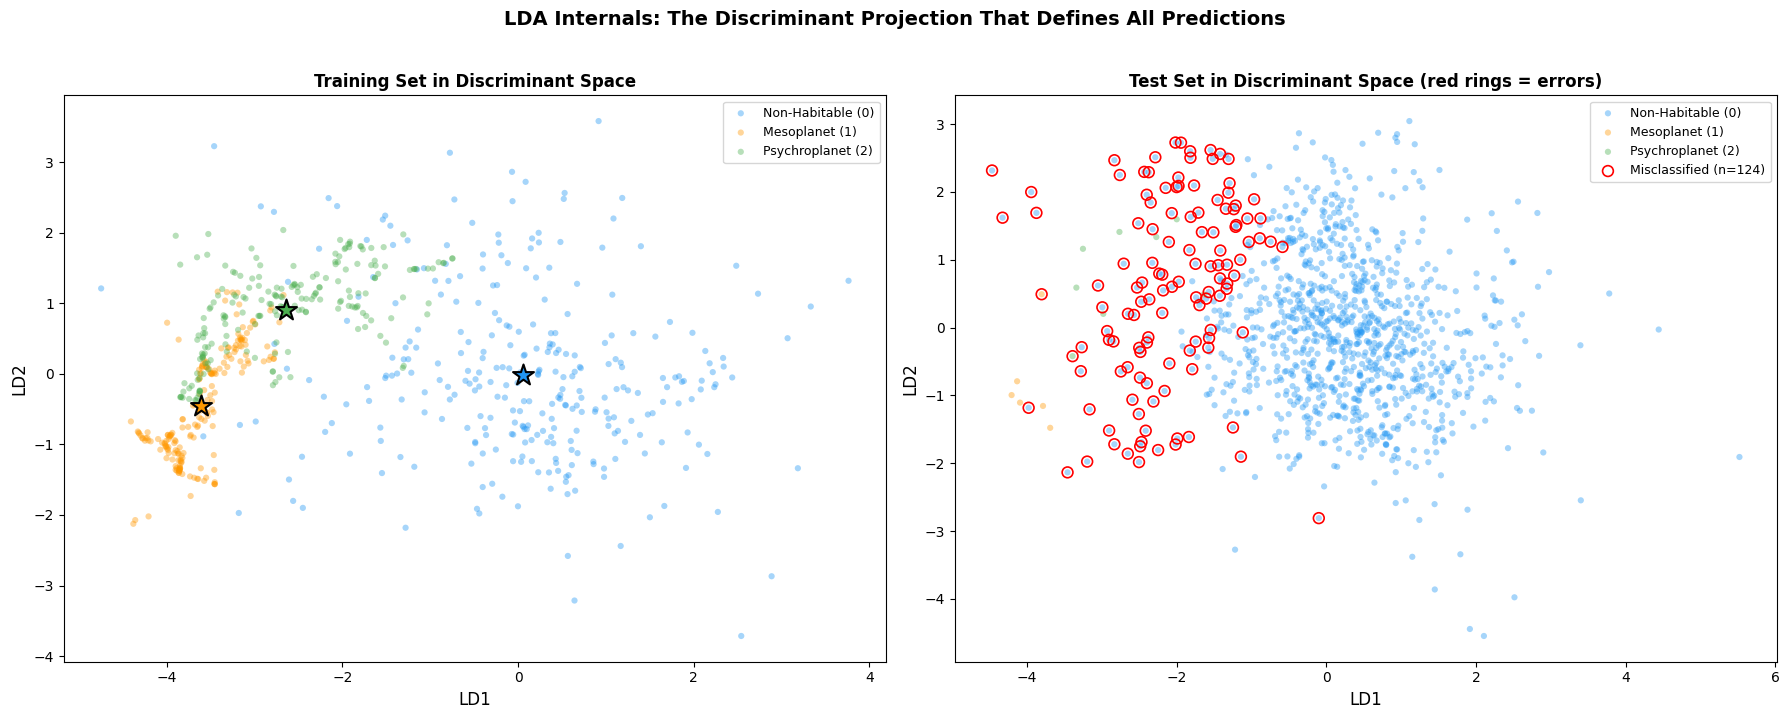

↑ LDA projects all 17 features onto 2 axes (LD1, LD2) that maximise class separation.
  Stars = class centroids. Every prediction = 'which centroid is closest?'
  Red rings on the right = test samples that were assigned to the wrong centroid.



In [5]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Left panel: Training data (balanced) ---
ax = axes[0]
# --- Left panel ---
for i, (cls, label, color) in enumerate(zip(classes, class_labels, colors)):
    mask = (y_train_bal == cls).values if hasattr(y_train_bal, 'values') else (y_train_bal == cls)
    ax.scatter(X_train_lda[mask, 0], X_train_lda[mask, 1],
               c=color, label=label, alpha=0.4, s=20, edgecolors="none")

centroids_lda = np.array([X_train_lda[(y_train_bal == c).values if hasattr(y_train_bal, 'values') else (y_train_bal == c)].mean(axis=0) for c in classes])

# Plot class centroids in discriminant space
centroids_lda = np.array([X_train_lda[y_train_bal == c].mean(axis=0) for c in classes])
for i, (cx, cy) in enumerate(centroids_lda):
    ax.scatter(cx, cy, c=colors[i], s=250, marker="*", edgecolors="black",
               linewidth=1.5, zorder=5)

ax.set_xlabel("LD1", fontsize=12)
ax.set_ylabel("LD2", fontsize=12)
ax.set_title("Training Set in Discriminant Space", fontsize=12, fontweight="bold")
ax.legend(fontsize=9, loc="best")

# --- Right panel: Test data (original distribution) ---
ax = axes[1]
for i, (cls, label, color) in enumerate(zip(classes, class_labels, colors)):
    mask = (y_test == cls).values if hasattr(y_test, 'values') else (y_test == cls)
    ax.scatter(X_test_lda[mask, 0], X_test_lda[mask, 1],
               c=color, label=label, alpha=0.4, s=20, edgecolors="none")

misclassified = (y_pred_lda != y_test).values if hasattr(y_test, 'values') else (y_pred_lda != y_test)

# Show misclassified test points
misclassified = y_pred_lda != y_test
ax.scatter(X_test_lda[misclassified, 0], X_test_lda[misclassified, 1],
           facecolors="none", edgecolors="red", s=60, linewidths=1.2,
           label=f"Misclassified (n={misclassified.sum()})", zorder=4)

ax.set_xlabel("LD1", fontsize=12)
ax.set_ylabel("LD2", fontsize=12)
ax.set_title("Test Set in Discriminant Space (red rings = errors)", fontsize=12, fontweight="bold")
ax.legend(fontsize=9, loc="best")

fig.suptitle("LDA Internals: The Discriminant Projection That Defines All Predictions",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
save_plot("lda_discriminant_space")
plt.show()

print("↑ LDA projects all 17 features onto 2 axes (LD1, LD2) that maximise class separation.")
print("  Stars = class centroids. Every prediction = 'which centroid is closest?'")
print("  Red rings on the right = test samples that were assigned to the wrong centroid.\n")

### DIAGNOSTIC PLOT 2: Feature Contributions to Discriminant Axes
LDA's weight matrix (scalings_) tells you exactly how much each original feature contributes to LD1 and LD2This is analogous to PCA loadings but optimised for class separation rather than variance.


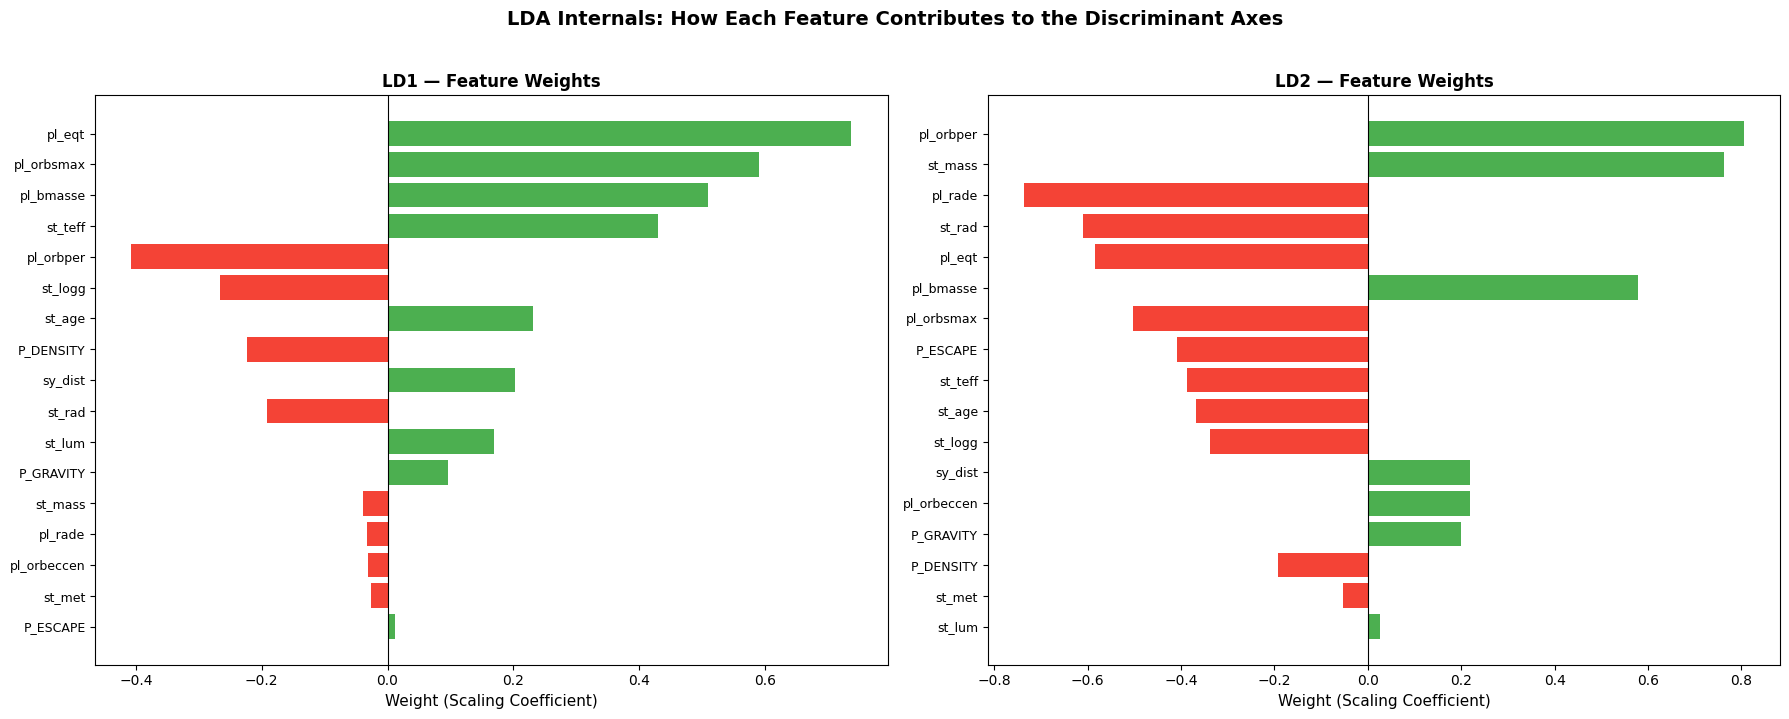

↑ These are the coefficients LDA uses to build LD1 and LD2 from the 17 raw features.
  Green = positive contribution, Red = negative. Longer bars = more influential features.
  Unlike tree-based 'importance', these are exact linear weights — fully interpretable.



In [6]:
scalings = lda_proj.scalings_  # ← was lda.scalings_
feature_names = FEATURES

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for comp_idx, ax in enumerate(axes):
    weights = scalings[:, comp_idx]
    sorted_idx = np.argsort(np.abs(weights))[::-1]

    sorted_weights = weights[sorted_idx]
    sorted_names = [feature_names[i] for i in sorted_idx]
    bar_colors = ["#4CAF50" if w > 0 else "#F44336" for w in sorted_weights]

    ax.barh(range(len(sorted_names)), sorted_weights, color=bar_colors, edgecolor="none")
    ax.set_yticks(range(len(sorted_names)))
    ax.set_yticklabels(sorted_names, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel("Weight (Scaling Coefficient)", fontsize=11)
    ax.set_title(f"LD{comp_idx + 1} — Feature Weights", fontsize=12, fontweight="bold")
    ax.axvline(0, color="black", lw=0.8)

fig.suptitle("LDA Internals: How Each Feature Contributes to the Discriminant Axes",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
save_plot("lda_feature_weights")
plt.show()

print("↑ These are the coefficients LDA uses to build LD1 and LD2 from the 17 raw features.")
print("  Green = positive contribution, Red = negative. Longer bars = more influential features.")
print("  Unlike tree-based 'importance', these are exact linear weights — fully interpretable.\n")

### DIAGNOSTIC PLOT 3: Class-Conditional Distributions Along Each LD Axis
Shows how well-separated the classes are along each discriminant axis individually.  
This reveals which axis does the heavy lifting.


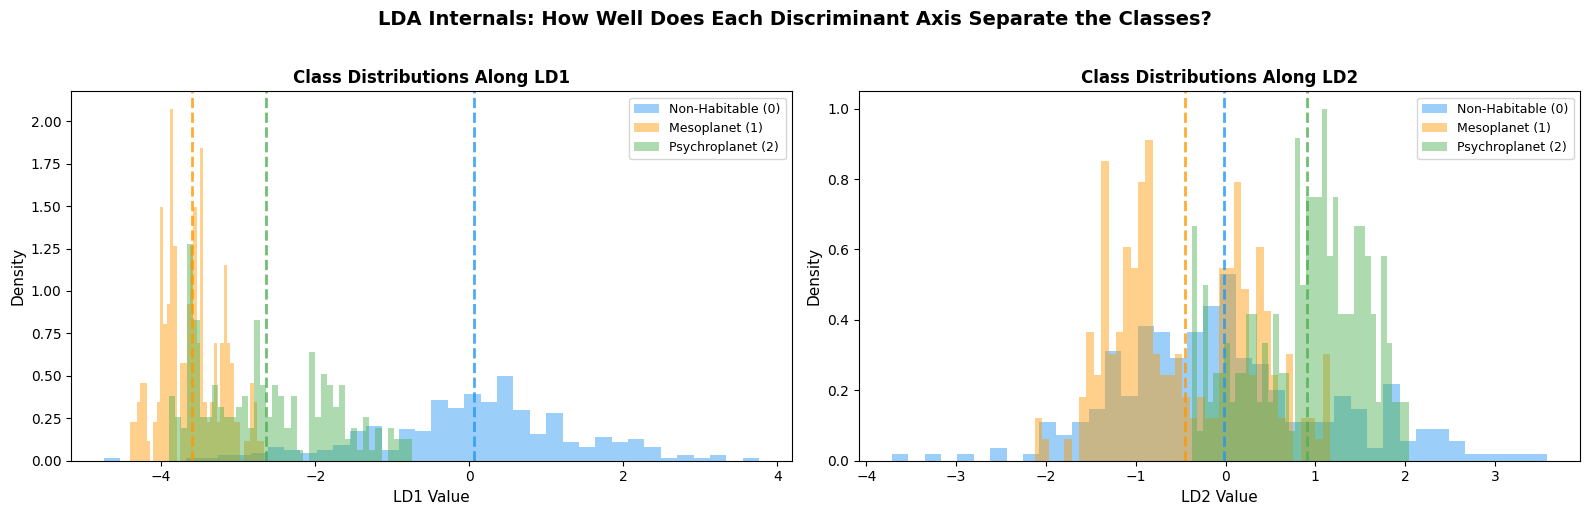

↑ Dashed lines = class means along each axis.
  LD1 typically handles the biggest class split; LD2 captures remaining separation.
  Overlapping histograms → confusion between those classes on that axis.



In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for comp_idx, ax in enumerate(axes):
    for i, (cls, label, color) in enumerate(zip(classes, class_labels, colors)):
        if hasattr(y_train_bal, 'values'):
            mask = (y_train_bal.values == cls)
        else:
            mask = (y_train_bal == cls)
        values = X_train_lda[mask, comp_idx]
        ax.hist(values, bins=40, alpha=0.45, color=color, label=label, density=True)
        ax.axvline(values.mean(), color=color, ls="--", lw=2, alpha=0.8)

    ax.set_xlabel(f"LD{comp_idx + 1} Value", fontsize=11)
    ax.set_ylabel("Density", fontsize=11)
    ax.set_title(f"Class Distributions Along LD{comp_idx + 1}", fontsize=12, fontweight="bold")
    ax.legend(fontsize=9)

fig.suptitle("LDA Internals: How Well Does Each Discriminant Axis Separate the Classes?",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
save_plot("lda_axis_distributions")
plt.show()

print("↑ Dashed lines = class means along each axis.")
print("  LD1 typically handles the biggest class split; LD2 captures remaining separation.")
print("  Overlapping histograms → confusion between those classes on that axis.\n")

### DIAGNOSTIC PLOT 4: Sweep-Aggregated Posterior Probabilities

Each panel shows the distribution of LDA's predicted class probabilities (`predict_proba`) for test samples whose **true** class is the panel title — aggregated across all 50 sweep seeds. With 50 splits × 6 mesoplanet test samples = **300 probability points** per minority panel (and 400 for psychroplanet), the violin shapes now carry real statistical mass. A well-calibrated LDA concentrates `P(true class)` near 1.0 most of the time.

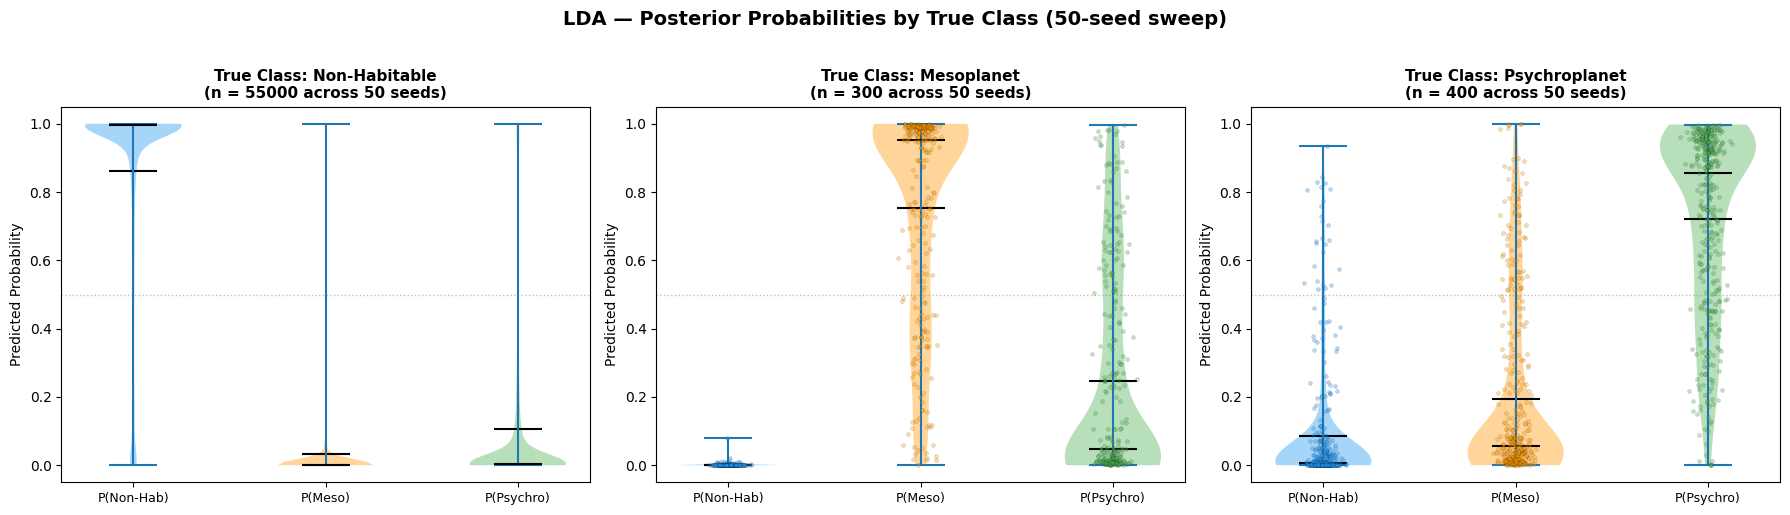

↑ Each panel = predicted class probabilities for samples whose TRUE class is labelled above,
  aggregated across all 50 sweep seeds.
  A well-calibrated LDA concentrates P(true class) near 1.0 across most splits.
  Wide spread on minority panels = the model is uncertain about those classes —
  expected given LDA's linear decision rule and only 6–8 test samples per minority per split.


In [8]:
plot_sweep_posterior_violins(sweep_lda)

print("↑ Each panel = predicted class probabilities for samples whose TRUE class is labelled above,")
print("  aggregated across all 50 sweep seeds.")
print("  A well-calibrated LDA concentrates P(true class) near 1.0 across most splits.")
print("  Wide spread on minority panels = the model is uncertain about those classes —")
print("  expected given LDA's linear decision rule and only 6–8 test samples per minority per split.")

## Metrics
### Classification Report

LDA — Classification Report (50-seed sweep)
Class               F1 mean     F1 std     F1 min     F1 max
----------------------------------------------------------------
Non-Habitable        0.9360     0.0083     0.9152     0.9539
Mesoplanet           0.2173     0.0587     0.0571     0.3226
Psychroplanet        0.1051     0.0248     0.0508     0.1684
----------------------------------------------------------------
Macro avg            0.4195     0.0233     0.3732     0.4762
Weighted avg         0.9262     0.0083     0.9053     0.9448

5-Fold CV F1 Macro: 0.8206 ± 0.0308

LDA — Performance Summary (50-seed sweep)

Per-class Precision and Recall (mean ± std)
                 Precision            Recall              
Non-Habitable    0.9995 ± 0.0008    0.8803 ± 0.0147
Mesoplanet       0.1278 ± 0.0358    0.7533 ± 0.2055
Psychroplanet    0.0565 ± 0.0136    0.7600 ± 0.1614
----------------------------------------------------------------
Macro avg        0.3946 ± 0.0135    0.7979 ± 0.0823
Wei

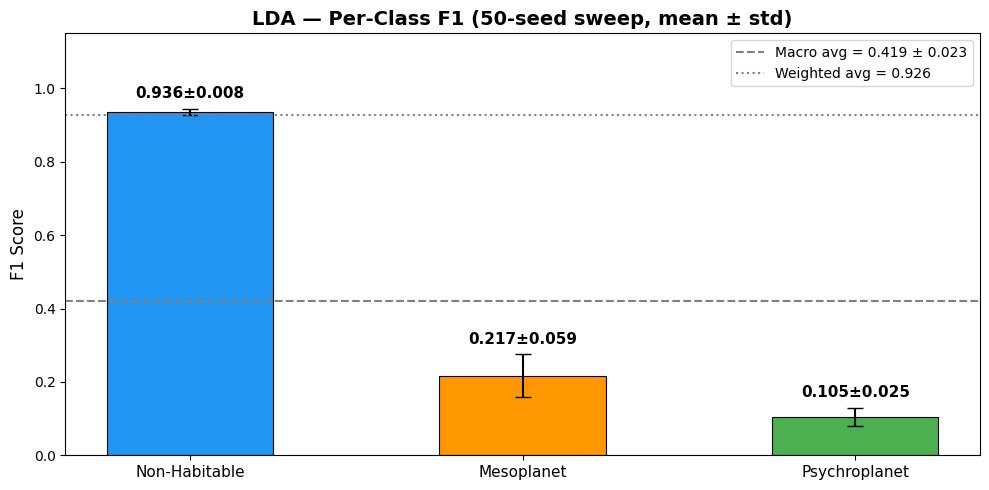

In [9]:
# Per-class F1 with mean ± std from the seed sweep
print_sweep_classification_report(sweep_lda)

# 5-fold CV on the balanced training set — orthogonal to sweep variance,
# measures within-seed tuning stability (different question).
cv_scores_lda = run_stratified_cv(lda, X_train_bal, y_train_bal)

# Cross-model comparison metrics: per-class P/R + aggregate robustness scores
# (MCC, balanced accuracy, minority F1 macro)
print_sweep_performance_summary(sweep_lda)

# Per-class bar chart with error bars from the sweep distribution
plot_sweep_f1_bar(sweep_lda)

### Confusion Matrix (Counts + Normalized)

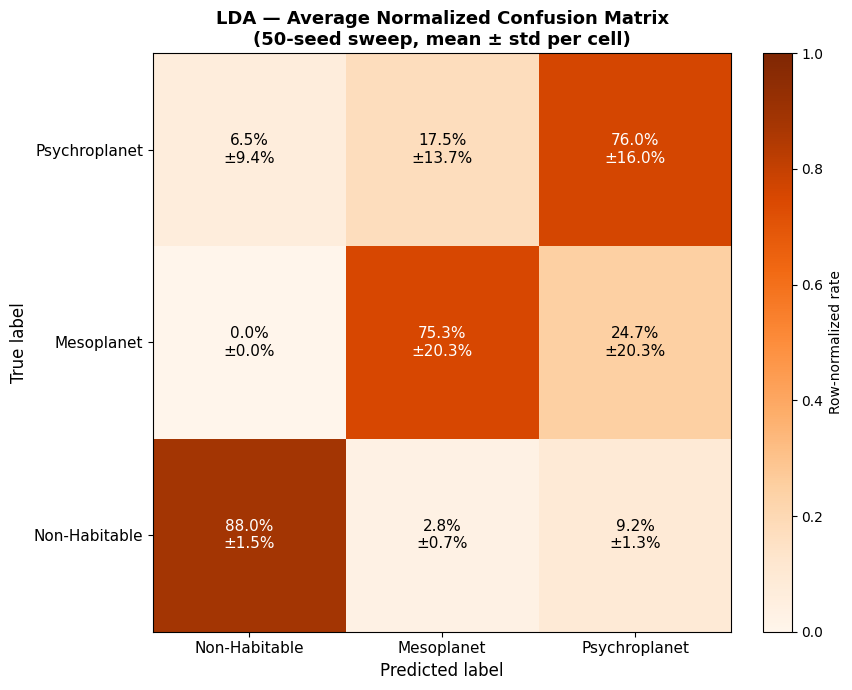

Key error patterns (50-seed sweep):
  Non-Habitable → predicted Mesoplanet: 30.30 ± 7.57 per split  (2.8% ± 0.7% of true Non-Habitable)
  Non-Habitable → predicted Psychroplanet: 101.42 ± 14.40 per split  (9.2% ± 1.3% of true Non-Habitable)
  Mesoplanet → predicted Psychroplanet: 1.48 ± 1.22 per split  (24.7% ± 20.3% of true Mesoplanet)
  Psychroplanet → predicted Non-Habitable: 0.52 ± 0.75 per split  (6.5% ± 9.4% of true Psychroplanet)
  Psychroplanet → predicted Mesoplanet: 1.40 ± 1.10 per split  (17.5% ± 13.7% of true Psychroplanet)


In [10]:
# Average row-normalized CM across all 50 seeds, annotated per-cell with std
plot_sweep_confusion_matrix(sweep_lda)

# Off-diagonal patterns: per-split count and per-class rate, both mean ± std
print_sweep_error_patterns(sweep_lda)

## Interpretation:
